#Importing everthing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math

In [ ]:
df_train = pd.read_csv('/content/train.csv')
df_train.head(10)
df_test = pd.read_csv('/content/test.csv')
df_test.head(10)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [ ]:
df_train.shape

(891, 12)

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Checking Survial for different features

In [ ]:
survival_count = df_train.groupby(['Pclass','Survived']).size().unstack()
print(survival_count)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


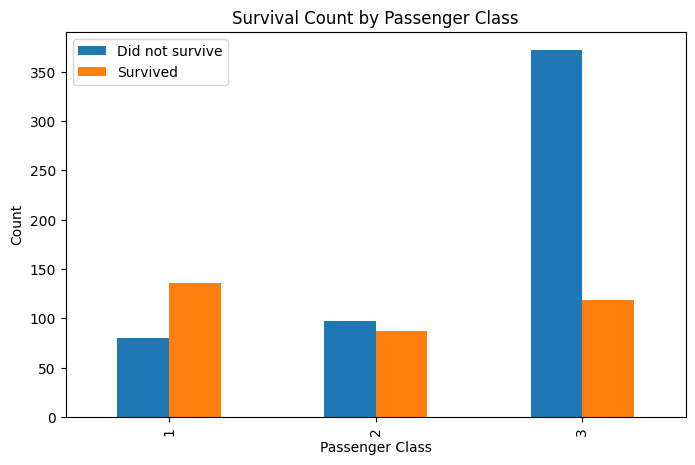

In [ ]:
survival_count.plot(kind='bar',figsize=(8,5))
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(["Did not survive", "Survived"])
plt.show()

We can see that the perecetage of people who did not survive are class 3 is highest which means rich ppl got priority

In [ ]:
bins = np.arange(0,85,5)
labels = [f"{i}-{i+4}" for i in bins[:-1]]
df_train['AgeGroup'] = pd.cut(
    df_train['Age'],
    bins=bins,
    labels=labels,
    right=False
)
print(df_train[['Age','AgeGroup']].head(10))

    Age AgeGroup
0  22.0    20-24
1  38.0    35-39
2  26.0    25-29
3  35.0    35-39
4  35.0    35-39
5   NaN      NaN
6  54.0    50-54
7   2.0      0-4
8  27.0    25-29
9  14.0    10-14


np arrange me 0 start 85 is end and 5 is the gap so the age will be divided into groups of 5 . We can alsi se that children got priority compared to adults






In [ ]:
age_survival = (
    df_train
    .groupby(['AgeGroup','Survived'])
    .size()
    .unstack()
)
print(age_survival)

Survived   0   1
AgeGroup        
0-4       13  27
5-9       11  11
10-14      9   7
15-19     52  34
20-24     75  39
25-29     68  38
30-34     55  40
35-39     39  33
40-44     30  18
45-49     25  16
50-54     18  14
55-59     10   6
60-64      9   6
65-69      4   0
70-74      6   0
75-79      0   0


/tmp/ipykernel_723/3196343834.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['AgeGroup','Survived'])


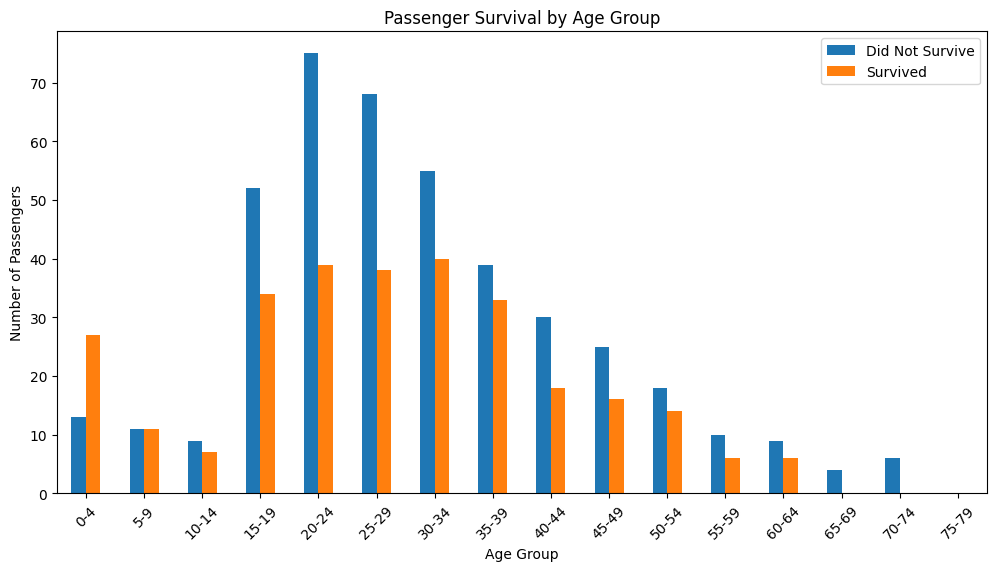

In [ ]:

age_survival.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Passenger Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.legend(["Did Not Survive", "Survived"])

plt.show()

We can see that childre3n got priority

In [ ]:
#correct this
gndsurvival_count = df_train.groupby(['Sex','Survived']).size().unstack()
print(gndsurvival_count)

Survived    0    1
Sex               
female     81  233
male      468  109


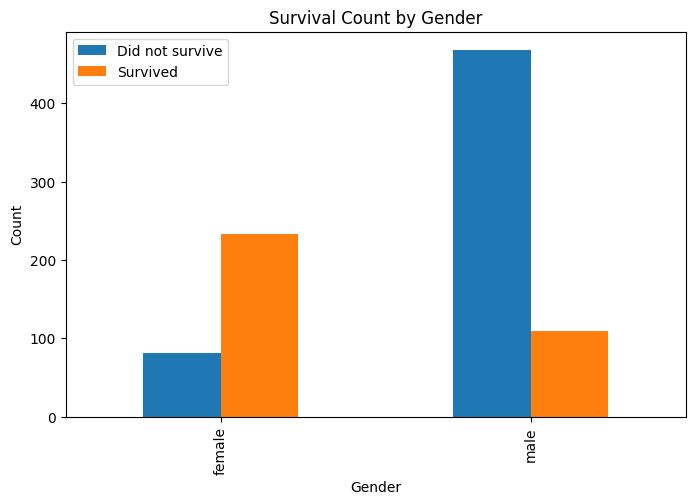

In [ ]:
gndsurvival_count.plot(kind='bar',figsize=(8,5))
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(["Did not survive", "Survived"])
plt.show()

We can see that females got way more priority


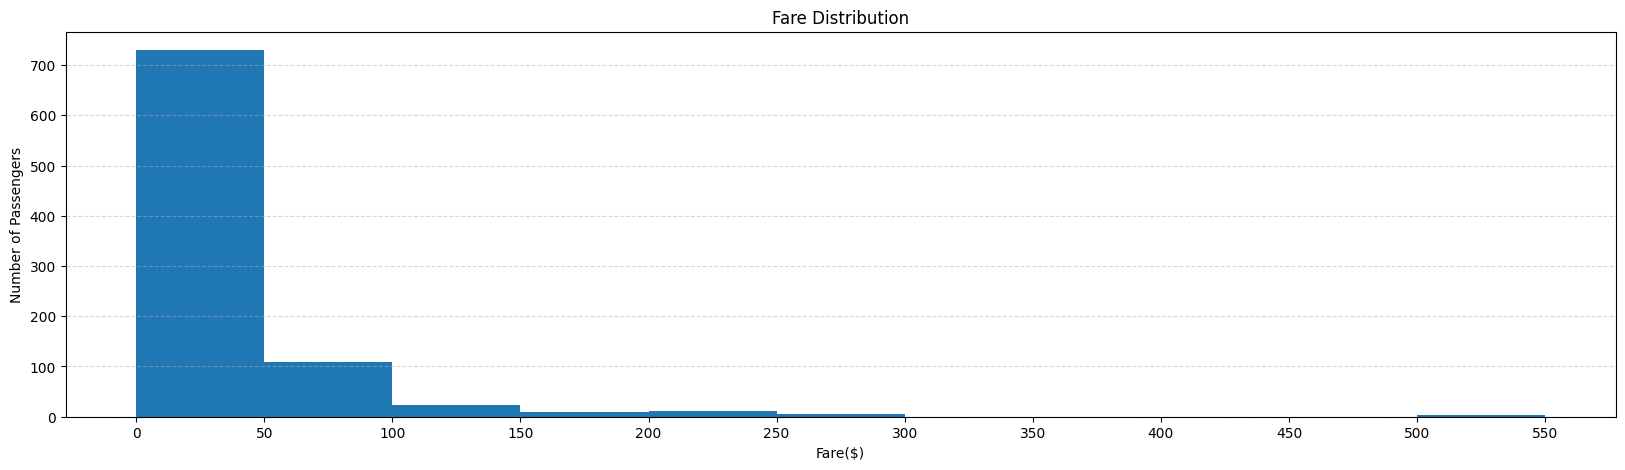

In [ ]:

plt.figure(figsize=(20,5))
bins = np.arange(0, df_train["Fare"].max() + 50, 50)
plt.hist(df_train["Fare"], bins=bins)
plt.xticks(np.arange(0, df_train["Fare"].max() + 50, 50))
plt.title("Fare Distribution")
plt.xlabel("Fare($)")
plt.ylabel("Number of Passengers")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

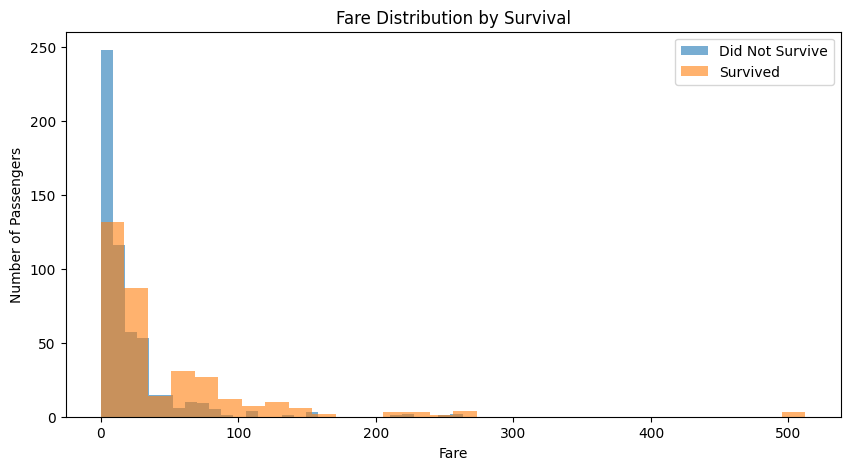

In [ ]:

survived = df_train[df_train["Survived"] == 1]["Fare"]
not_survived = df_train[df_train["Survived"] == 0]["Fare"]

plt.figure(figsize=(10,5))

plt.hist(not_survived, bins=30, alpha=0.6, label="Did Not Survive")
plt.hist(survived, bins=30, alpha=0.6, label="Survived")

plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.legend()

plt.show()

We can see from the graph that people who paid more fare got more priority in saving

#Missing data

Fixing Cabin by making hascabin feature

In [ ]:

missing_cabin = df_train["Cabin"].isnull().sum()
print("Missing Cabin Values:", missing_cabin)
notmissing_cabin = df_train["Cabin"].notnull().sum()
print("notMissing Cabin Values:", notmissing_cabin)
total = len(df_train)
percentage_cabin = (missing_cabin / total) * 100
print("Percentage of Missing Cabin Values:", round(percentage_cabin, 2))


Missing Cabin Values: 687
notMissing Cabin Values: 204
Percentage of Missing Cabin Values: 77.1


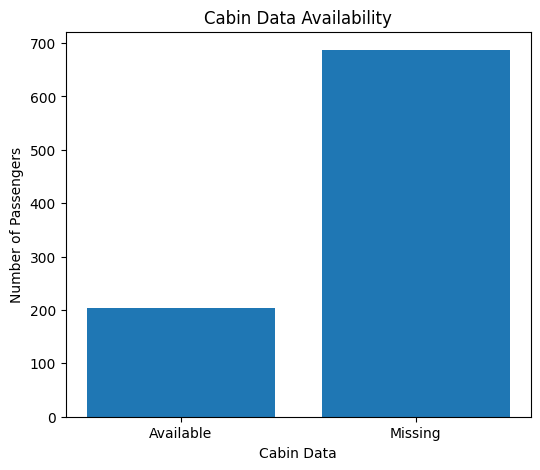

In [ ]:

notmissing_cabin = df_train["Cabin"].notnull().sum()
missing_cabin = df_train["Cabin"].isnull().sum()
plt.figure(figsize=(6,5))
plt.bar(
    ["Available", "Missing"],
    [notmissing_cabin, missing_cabin]
)
plt.title("Cabin Data Availability")
plt.xlabel("Cabin Data")
plt.ylabel("Number of Passengers")
plt.show()


In [ ]:
# df_train = df_train.drop(columns=["Cabin"])

In [ ]:
df_train["HasCabin"] = df_train["Cabin"].notnull().astype(int)
print(df_train["HasCabin"].value_counts())
print(df_train.groupby("HasCabin")["Survived"].mean())

HasCabin
0    687
1    204
Name: count, dtype: int64
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [ ]:
missing_age= df_train["Age"].isnull().sum()
print("The total missing age :",missing_age)
notmissing_age =df_train["Age"].notnull().sum()
print("The total  not missing age :",notmissing_age)
percentage_age= (missing_age/total)*100
print("Percentage of Missing age Values:", round(percentage_age, 2))

The total missing age : 177
The total  not missing age : 714
Percentage of Missing age Values: 19.87


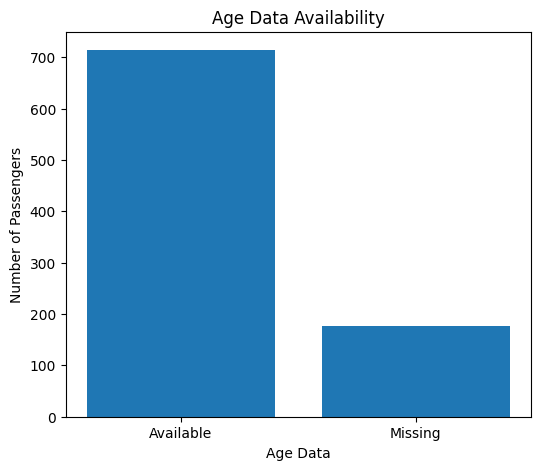

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(
    ["Available", "Missing"],
    [notmissing_age, missing_age]
)
plt.title("Age Data Availability")
plt.xlabel("Age Data")
plt.ylabel("Number of Passengers")
plt.show()

In [ ]:
mode_embarked = df_train["Embarked"].mode()[0]
df_train["Embarked"] = df_train["Embarked"].fillna(mode_embarked)
print("Missing values in Embarked:", df_train["Embarked"].isnull().sum())

Missing values in Embarked: 0


#Data preprocessing
Age:
We gonna take the median age of the class from which the age is not given and give it the median age


In [ ]:
print(df_train.groupby("Pclass")["Age"].median())
df_train["Age"]=(
    df_train
    .groupby("Pclass")["Age"]
    .transform(lambda x: x.fillna(x.median()))
)
print(df_train["Age"])
print(df_train["Age"].isnull().sum())

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64
0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    24.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64
0


In [ ]:

mode_embarked = df_train["Embarked"].mode()[0]


df_train["Embarked"] = df_train["Embarked"].fillna(mode_embarked)


print(df_train["Embarked"].isnull().sum())

0


In [ ]:

# df_train["Deck"] = df_train["Cabin"].str[0]
# df_train["Deck"] = df_train["Deck"].fillna("Unknown")
# print(df_train["Deck"].isnull().sum())

#Feature engineering
,-finds the comma
\s* skips spaces


Extracting title from each person it can give details about status and gender of the person


In [ ]:
df_train["Title"] = df_train["Name"].str.extract(r",\s*([^\.]+)\.")
print(df_train["Title"].head())

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Title, dtype: object


This gives you family size which makes the 2 couloumns joined as they bith of them are doesn't help the prediction that much cmonining them will give a better feature for prediction

+1 because of urself

In [ ]:
df_train["FamilySize"] = (df_train["SibSp"] +df_train["Parch"] +1)
print(df_train["FamilySize"].head())

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64


In [ ]:
df_train["IsAlone"] = (df_train["FamilySize"] == 1).astype(int)
print(df_train["IsAlone"].head())

0    0
1    0
2    1
3    0
4    1
Name: IsAlone, dtype: int64


Age copy from above

In [ ]:
bins = np.arange(0,85,5)
labels = [f"{i}-{i+4}" for i in bins[:-1]]
df_train['AgeGroup'] = pd.cut(
    df_train['Age'],
    bins=bins,
    labels=labels,
    right=False
)
print(df_train[['Age','AgeGroup']].head(10))

    Age AgeGroup
0  22.0    20-24
1  38.0    35-39
2  26.0    25-29
3  35.0    35-39
4  35.0    35-39
5  24.0    20-24
6  54.0    50-54
7   2.0      0-4
8  27.0    25-29
9  14.0    10-14


In [ ]:
# bins = np.arange(0,550,50)
# labels = [f"{i}-{i+49}" for i in bins[:-1]]
# df_train["FareGroup"] = pd.cut(
#     df_train["Fare"],
#     bins=bins,
#     labels=labels,
#     right=False
# )
# print(df_train[['Fare','FareGroup']].head(10))
# # df_train["FareGroup"], fare_bin_edges = pd.qcut(
# #     df_train["Fare"],
# #     q=4,                      # try 4-6 and compare via grid search
# #     labels=False,
# #     retbins=True,
# #     duplicates="drop"
# # )
# # print(df_train[['Fare','FareGroup']].head(10))

In [ ]:
df_train = pd.get_dummies(
    df_train,
    columns=["Embarked"],
    dtype=int
)

Turning sex into number because compputers only understand numbers

In [ ]:
df_train["Sex"] = df_train["Sex"].map({"male": 0,"female": 1})
print(df_train[["Sex" ]].head(10))


   Sex
0    0
1    1
2    1
3    1
4    0
5    0
6    0
7    0
8    1
9    1


In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,AgeGroup,HasCabin,Title,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,20-24,0,Mr,2,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,35-39,1,Mrs,2,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,25-29,0,Miss,1,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,35-39,1,Mrs,2,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,35-39,0,Mr,1,1,0,0,1


In [ ]:
# Bucket rare titles into a single "Rare" category
rare_titles = [
    "Capt", "Col", "Countess", "Don", "Dona", "Jonkheer",
    "Lady", "Major", "Mlle", "Mme", "Ms", "Sir"
]

df_train["Title"] = df_train["Title"].replace(rare_titles, "Rare")

print(df_train["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             13
Dr                7
Rev               6
the Countess      1
Name: count, dtype: int64


Turning titles into hot - one code just like embroked because computers can only understand numbers

In [ ]:
title_dummies_train = pd.get_dummies(df_train["Title"], prefix="Title", dtype=int)

# 2. Concatenate them onto the original training DataFrame
df_train = pd.concat([df_train, title_dummies_train], axis=1)

In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,Title_Dr,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_Rev,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,0,1,0,0,0,1,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,0,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,0,1,0,0,1,0,0,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,1,0,0,0,0,1,0,0,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,0,1,0,0,0,1,0,0,0,0


In [ ]:
print(df_train["Title"].value_counts(normalize=True) * 100)

Title
Mr              58.024691
Miss            20.426487
Mrs             14.029181
Master           4.489338
Rare             1.459035
Dr               0.785634
Rev              0.673401
the Countess     0.112233
Name: proportion, dtype: float64


These are features i used explaintion in pdf

In [ ]:
features = [
    "Pclass", "Sex", "AgeGroup", "Fare",
    "IsAlone", "FamilySize",
    "Embarked_C", "Embarked_Q", "Embarked_S",
    "Title_Master", "Title_Miss", "Title_Mr", "Title_Mrs",
    "Title_Rev", "Title_Dr", "Title_Rare",
    "HasCabin"
]
X = df_train[features]
y = df_train["Survived"]
print(X.columns)

Index(['Pclass', 'Sex', 'AgeGroup', 'Fare', 'IsAlone', 'FamilySize',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rev', 'Title_Dr', 'Title_Rare',
       'HasCabin'],
      dtype='object')


In [ ]:
print(X.head())
print(X.dtypes)

   Pclass  Sex AgeGroup     Fare  IsAlone  FamilySize  Embarked_C  Embarked_Q  \
0       3    0    20-24   7.2500        0           2           0           0   
1       1    1    35-39  71.2833        0           2           1           0   
2       3    1    25-29   7.9250        1           1           0           0   
3       1    1    35-39  53.1000        0           2           0           0   
4       3    0    35-39   8.0500        1           1           0           0   

   Embarked_S  Title_Master  Title_Miss  Title_Mr  Title_Mrs  Title_Rev  \
0           1             0           0         1          0          0   
1           0             0           0         0          1          0   
2           1             0           1         0          0          0   
3           1             0           0         0          1          0   
4           1             0           0         1          0          0   

   Title_Dr  Title_Rare  HasCabin  
0         0           0   

As computer only understand number we have convert cat to number

In [ ]:

X["AgeGroup"] = X["AgeGroup"].cat.codes
#X["FareGroup"] = X["FareGroup"].cat.codes

# Convert Deck (object) to category first, then to codes
#X["Deck"] = X["Deck"].astype("category").cat.codes
print(X.dtypes)
print(X.head())

Pclass            int64
Sex               int64
AgeGroup           int8
Fare            float64
IsAlone           int64
FamilySize        int64
Embarked_C        int64
Embarked_Q        int64
Embarked_S        int64
Title_Master      int64
Title_Miss        int64
Title_Mr          int64
Title_Mrs         int64
Title_Rev         int64
Title_Dr          int64
Title_Rare        int64
HasCabin          int64
dtype: object
   Pclass  Sex  AgeGroup     Fare  IsAlone  FamilySize  Embarked_C  \
0       3    0         4   7.2500        0           2           0   
1       1    1         7  71.2833        0           2           1   
2       3    1         5   7.9250        1           1           0   
3       1    1         7  53.1000        0           2           0   
4       3    0         7   8.0500        1           1           0   

   Embarked_Q  Embarked_S  Title_Master  Title_Miss  Title_Mr  Title_Mrs  \
0           0           1             0           0         1          0   
1    

/tmp/ipykernel_723/1863302858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["AgeGroup"] = X["AgeGroup"].cat.codes


In [ ]:
age_mapping = dict(enumerate(df_train["AgeGroup"].astype("category").cat.categories))

print("AgeGroup Mapping:")
for code, group in age_mapping.items():
    print(f"{code} --> {group}")
#     fare_mapping = dict(enumerate(df_train["FareGroup"].astype("category").cat.categories))

# print("FareGroup Mapping:")
# for code, group in fare_mapping.items():
#     print(f"{code} --> {group}")

AgeGroup Mapping:
0 --> 0-4
1 --> 5-9
2 --> 10-14
3 --> 15-19
4 --> 20-24
5 --> 25-29
6 --> 30-34
7 --> 35-39
8 --> 40-44
9 --> 45-49
10 --> 50-54
11 --> 55-59
12 --> 60-64
13 --> 65-69
14 --> 70-74
15 --> 75-79


##Preprocessing test data


doing the same thing for test


In [ ]:
df_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [ ]:
# df_test = df_train.drop(columns=["Cabin"])

In [ ]:

# df_test["Deck"] = df_test["Cabin"].str[0]
# df_test["Deck"] = df_test["Deck"].fillna("Unknown")
# print(df_test["Deck"].isnull().sum())

In [ ]:
print(df_test.groupby("Pclass")["Age"].median())
df_test["Age"]=(
    df_test
    .groupby("Pclass")["Age"]
    .transform(lambda x: x.fillna(x.median()))
)
print(df_test["Age"])
print(df_test["Age"].isnull().sum())

Pclass
1    42.0
2    26.5
3    24.0
Name: Age, dtype: float64
0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    24.0
414    39.0
415    38.5
416    24.0
417    24.0
Name: Age, Length: 418, dtype: float64
0


In [ ]:
# Find the most frequent embarkation port
mode_embarked = df_test["Embarked"].mode()[0]

# Fill missing values with the mode
df_test["Embarked"] = df_test["Embarked"].fillna(mode_embarked)

# Verify
print(df_test["Embarked"].isnull().sum())

0


In [ ]:
df_test["Title"] = df_test["Name"].str.extract(r",\s*([^\.]+)\.")
print(df_test["Title"].head())

0     Mr
1    Mrs
2     Mr
3     Mr
4    Mrs
Name: Title, dtype: object


In [ ]:
df_test["Sex"] = df_test["Sex"].map({"male": 0,"female": 1})

In [ ]:
df_test["FamilySize"] = (df_test["SibSp"] +df_test["Parch"] +1)
print(df_test["FamilySize"].head())

0    1
1    2
2    1
3    1
4    3
Name: FamilySize, dtype: int64


In [ ]:
df_test["IsAlone"] = (df_test["FamilySize"] == 1).astype(int)
print(df_test["IsAlone"].head())

0    1
1    0
2    1
3    1
4    0
Name: IsAlone, dtype: int64


In [ ]:
bins = np.arange(0,85,5)
labels = [f"{i}-{i+4}" for i in bins[:-1]]
df_test['AgeGroup'] = pd.cut(
    df_test['Age'],
    bins=bins,
    labels=labels,
    right=False
)
print(df_test[['Age','AgeGroup']].head(10))

    Age AgeGroup
0  34.5    30-34
1  47.0    45-49
2  62.0    60-64
3  27.0    25-29
4  22.0    20-24
5  14.0    10-14
6  30.0    30-34
7  26.0    25-29
8  18.0    15-19
9  21.0    20-24


In [ ]:
df_test["Fare"] = df_test["Fare"].fillna(
    df_test.groupby("Pclass")["Fare"].transform("median")
)

In [ ]:
bins = np.arange(0,550,50)
labels = [f"{i}-{i+49}" for i in bins[:-1]]
df_test["FareGroup"] = pd.cut(
    df_test["Fare"],
    bins=bins,
    labels=labels,
    right=False
)
print(df_test[['Fare','FareGroup']].head(10))


      Fare FareGroup
0   7.8292      0-49
1   7.0000      0-49
2   9.6875      0-49
3   8.6625      0-49
4  12.2875      0-49
5   9.2250      0-49
6   7.6292      0-49
7  29.0000      0-49
8   7.2292      0-49
9  24.1500      0-49


In [ ]:
title_dummies_test = pd.get_dummies(df_test["Title"], prefix="Title", dtype=int)
df_test = pd.concat([df_test, title_dummies_test], axis=1)

In [ ]:
print(df_test.head())

   PassengerId  Pclass                                          Name  Sex  \
0          892       3                              Kelly, Mr. James    0   
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1   
2          894       2                     Myles, Mr. Thomas Francis    0   
3          895       3                              Wirz, Mr. Albert    0   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1   

    Age  SibSp  Parch   Ticket     Fare Cabin  ... FareGroup Title_Col  \
0  34.5      0      0   330911   7.8292   NaN  ...      0-49         0   
1  47.0      1      0   363272   7.0000   NaN  ...      0-49         0   
2  62.0      0      0   240276   9.6875   NaN  ...      0-49         0   
3  27.0      0      0   315154   8.6625   NaN  ...      0-49         0   
4  22.0      1      1  3101298  12.2875   NaN  ...      0-49         0   

   Title_Dona  Title_Dr Title_Master Title_Miss  Title_Mr  Title_Mrs  \
0           0       

In [ ]:
df_test["AgeGroup"] = df_test["AgeGroup"].cat.codes
df_test["FareGroup"] = df_test["FareGroup"].cat.codes
#df_test["Deck"] = df_test["Deck"].astype("category").cat.codes
# One-hot encode Embarked
embarked_dummies = pd.get_dummies(df_test["Embarked"], prefix="Embarked")


df_test = pd.concat([df_test , embarked_dummies], axis=1)


for col in ["Embarked_C", "Embarked_Q", "Embarked_S"]:
    if col not in df_test.columns:
        df_test[col] = 0


df_test.drop(columns=["Embarked"], inplace=True)

print(df_test.head())

   PassengerId  Pclass                                          Name  Sex  \
0          892       3                              Kelly, Mr. James    0   
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1   
2          894       2                     Myles, Mr. Thomas Francis    0   
3          895       3                              Wirz, Mr. Albert    0   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1   

    Age  SibSp  Parch   Ticket     Fare Cabin  ... Title_Dr  Title_Master  \
0  34.5      0      0   330911   7.8292   NaN  ...        0             0   
1  47.0      1      0   363272   7.0000   NaN  ...        0             0   
2  62.0      0      0   240276   9.6875   NaN  ...        0             0   
3  27.0      0      0   315154   8.6625   NaN  ...        0             0   
4  22.0      1      1  3101298  12.2875   NaN  ...        0             0   

   Title_Miss  Title_Mr  Title_Mrs  Title_Ms  Title_Rev  Embarked_C  \
0  

In [ ]:
# Loop through all the columns your model expects
for col in features:
    # If the test set is missing the column (like 'Title_Capt'), add it and fill with 0
    if col not in df_test.columns:
        df_test[col] = 0

# Now, this will run perfectly without any KeyErrors!

In [ ]:
df_test["Title"] = df_test["Title"].replace(rare_titles, "Rare")

print(df_test["Title"].value_counts())

Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        4
Rev         2
Dr          1
Name: count, dtype: int64


In [ ]:
print(df_test["Title"].value_counts(normalize=True) * 100)

Title
Mr        57.416268
Miss      18.660287
Mrs       17.224880
Master     5.023923
Rare       0.956938
Rev        0.478469
Dr         0.239234
Name: proportion, dtype: float64


In [ ]:
df_test["HasCabin"] = df_test["Cabin"].notnull().astype(int)

In [ ]:
feature = [
    "Pclass", "Sex", "AgeGroup", "Fare",
    "IsAlone", "FamilySize",
    "Embarked_C", "Embarked_Q", "Embarked_S",
    "Title_Master", "Title_Miss", "Title_Mr", "Title_Mrs",
    "Title_Rev", "Title_Dr", "Title_Rare",
]

X_test = df_test[feature]
print(df_test.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup',
       'FareGroup', 'Title_Col', 'Title_Dona', 'Title_Dr', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Rare', 'HasCabin'],
      dtype='object')


#Decision tree


1-(342/891)^2-(549/891)^2 = titanic gini

In [ ]:
total_survived = df_train["Survived"].sum()
total_not_survived=len(df_train)-total_survived
total=len(df_train)
print("Total Survived:",total_survived)
print("Total Not Survived:",total_not_survived)
print("Total:",total)

Total Survived: 342
Total Not Survived: 549
Total: 891


In [ ]:
class Node:
    def __init__(self,
                 feature=None,
                 threshold=None,
                 left=None,
                 right=None,
                 value=None):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [ ]:



class DecisionTree:

    def __init__(self,
                 max_depth=None,
                 min_samples_split=2,
                 criterion="gini"):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None

    def gini_impurity(self, y):
        # Vectorized with numpy for speed (same result as looping over labels)
        y = np.asarray(y)

        total_samples = len(y)

        if total_samples == 0:
            return 0

        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / total_samples

        gini = 1 - np.sum(probabilities ** 2)

        return gini

    def split_data(self, X, y, feature, threshold):
        # Vectorized with a boolean mask instead of a row-by-row Python loop
        mask = X[feature].values <= threshold

        left_X = X[mask]
        right_X = X[~mask]

        left_y = y[mask]
        right_y = y[~mask]

        return left_X, right_X, left_y, right_y

    def information_gain(self, X, y, feature, threshold):

        left_X, right_X, left_y, right_y = self.split_data(
            X, y, feature, threshold
        )

        if len(left_y) == 0 or len(right_y) == 0:
            return 0

        parent_gini = self.gini_impurity(y)

        left_gini = self.gini_impurity(left_y)
        right_gini = self.gini_impurity(right_y)

        total = len(y)

        weighted_gini = (
            (len(left_y) / total) * left_gini +
            (len(right_y) / total) * right_gini
        )

        gain = parent_gini - weighted_gini

        return gain

    def show_gini_calculation(self, X, y, feature, threshold):
        # Optional helper for manually verifying/printing a split's gini math

        left_X, right_X, left_y, right_y = self.split_data(
            X, y, feature, threshold
        )

        parent_gini = self.gini_impurity(y)
        left_gini = self.gini_impurity(left_y)
        right_gini = self.gini_impurity(right_y)

        print("=" * 50)
        print(f"Feature   : {feature}")
        print(f"Threshold : {threshold}")
        print("=" * 50)

        print("\nParent Node")
        print("-" * 30)
        print(f"Total Samples = {len(y)}")
        print(pd.Series(y).value_counts().sort_index())
        print(f"Parent Gini = {parent_gini:.4f}")

        print("\nLeft Node")
        print("-" * 30)
        print(f"Samples = {len(left_y)}")
        print(pd.Series(left_y).value_counts().sort_index())
        print(f"Left Gini = {left_gini:.4f}")

        print("\nRight Node")
        print("-" * 30)
        print(f"Samples = {len(right_y)}")
        print(pd.Series(right_y).value_counts().sort_index())
        print(f"Right Gini = {right_gini:.4f}")

        weighted_gini = (
            (len(left_y) / len(y)) * left_gini +
            (len(right_y) / len(y)) * right_gini
        )
        information_gain = parent_gini - weighted_gini

        print("\nWeighted Gini Calculation")
        print("-" * 30)
        print(f"({len(left_y)}/{len(y)}) × {left_gini:.4f} + ({len(right_y)}/{len(y)}) × {right_gini:.4f}")
        print(f"Weighted Gini = {weighted_gini:.4f}")

        print("\nInformation Gain")
        print("-" * 30)
        print(f"{parent_gini:.4f} - {weighted_gini:.4f}")
        print(f"Information Gain = {information_gain:.4f}")
        print("=" * 50)

    def best_split(self, X, y):

        best_feature = None
        best_threshold = None
        best_gain = -1

        for feature in X.columns:

            thresholds = X[feature].unique()

            for threshold in thresholds:

                gain = self.information_gain(
                    X,
                    y,
                    feature,
                    threshold
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def fit(self, X, y, depth=0):

        # Stopping Conditions

        if len(set(y)) == 1:
            node = Node(value=y.iloc[0])
            if depth == 0:
                self.root = node
            return node

        if len(y) < self.min_samples_split:
            prediction = y.mode()[0]
            node = Node(value=prediction)
            if depth == 0:
                self.root = node
            return node

        if self.max_depth is not None and depth >= self.max_depth:
            prediction = y.mode()[0]
            node = Node(value=prediction)
            if depth == 0:
                self.root = node
            return node

        feature, threshold, gain = self.best_split(X, y)

        if feature is None or gain <= 0:
            prediction = y.mode()[0]
            node = Node(value=prediction)
            if depth == 0:
                self.root = node
            return node

        left_X, right_X, left_y, right_y = self.split_data(
            X,
            y,
            feature,
            threshold
        )

        left_child = self.fit(
            left_X,
            left_y,
            depth + 1
        )

        right_child = self.fit(
            right_X,
            right_y,
            depth + 1
        )

        node = Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

        if depth == 0:
            self.root = node

        return node

    def predict_sample(self, x):

        node = self.root

        while node.value is None:

            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.value

    def predict(self, X):

        predictions = []

        for i in range(len(X)):
            prediction = self.predict_sample(X.iloc[i])
            predictions.append(int(prediction))

        return predictions

In [ ]:
tree = DecisionTree()

for feature in X.columns:

    best_threshold = None
    best_gini = float("inf")
    best_gain = -1

    thresholds = X[feature].unique()

    for threshold in thresholds:

        left_X, right_X, left_y, right_y = tree.split_data(
            X, y, feature, threshold
        )

        if len(left_y) == 0 or len(right_y) == 0:
            continue

        left_gini = tree.gini_impurity(left_y)
        right_gini = tree.gini_impurity(right_y)

        weighted_gini = (
            (len(left_y) / len(y)) * left_gini +
            (len(right_y) / len(y)) * right_gini
        )

        gain = tree.information_gain(X, y, feature, threshold)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold
            best_gini = weighted_gini

    print(f"{feature}")
    print(f" Best Threshold : {best_threshold}")
    print(f" Weighted Gini : {best_gini:.4f}")
    print(f" Information Gain : {best_gain:.4f}")
    print("-" * 40)

Pclass
 Best Threshold : 2
 Weighted Gini : 0.4239
 Information Gain : 0.0491
----------------------------------------
Sex
 Best Threshold : 0
 Weighted Gini : 0.3334
 Information Gain : 0.1396
----------------------------------------
AgeGroup
 Best Threshold : 0
 Weighted Gini : 0.4644
 Information Gain : 0.0086
----------------------------------------
Fare
 Best Threshold : 10.4625
 Weighted Gini : 0.4304
 Information Gain : 0.0426
----------------------------------------
IsAlone
 Best Threshold : 0
 Weighted Gini : 0.4535
 Information Gain : 0.0196
----------------------------------------
FamilySize
 Best Threshold : 1
 Weighted Gini : 0.4535
 Information Gain : 0.0196
----------------------------------------
Embarked_C
 Best Threshold : 0
 Weighted Gini : 0.4596
 Information Gain : 0.0134
----------------------------------------
Embarked_Q
 Best Threshold : 0
 Weighted Gini : 0.4730
 Information Gain : 0.0000
----------------------------------------
Embarked_S
 Best Threshold : 0
 

In [ ]:
left_X, right_X, left_y, right_y = tree.split_data(
    X,
    y,
    "Sex",
    0
)

print("Left Samples :", len(left_y))
print("Right Samples:", len(right_y))

print("\nLeft Class Counts")
print(left_y.value_counts())

print("\nRight Class Counts")
print(right_y.value_counts())

Left Samples : 577
Right Samples: 314

Left Class Counts
Survived
0    468
1    109
Name: count, dtype: int64

Right Class Counts
Survived
1    233
0     81
Name: count, dtype: int64


Gini(left)=1-(468/577)^2-(109/577)^2 = 0.306



Gini(right)=1-(233/314)^2-(81/314)^2 = 0.383


Gini(Weighted) = 1-(577/577+314)*0.306-(314/577+314)*0.383=0.33312

In [ ]:
tree = DecisionTree(
    max_depth=5,
    min_samples_split=2
)

In [ ]:
tree.root = tree.fit(X, y)

In [ ]:
print(tree.root.feature)
print(tree.root.threshold)

Title_Mr
0


In [ ]:
print(tree.root.left)
print(tree.root.right)

In [ ]:
print(tree.root.left.value)
print(tree.root.right.value)

None
None


In [ ]:
prediction = tree.predict_sample(X.iloc[0])

print(prediction)

0


In [ ]:
predictions = tree.predict(X)

print(predictions[:10])

[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]


In [ ]:
correct = 0

for actual, predicted in zip(y, predictions):
    if actual == predicted:
        correct += 1

accuracy = correct / len(y)

print("Accuracy:", accuracy)

Accuracy: 0.8428731762065096


#Grid search cv
fold divides data into 5 random parts

In [ ]:
 def create_folds(X, y, k):

     fold_size = len(X) // k
     folds = []

     for i in range(k):

         start = i * fold_size

         if i == k - 1:
             end = len(X)
         else:
             end = (i + 1) * fold_size

         X_fold = X.iloc[start:end]
         y_fold = y.iloc[start:end]

         folds.append((X_fold, y_fold))

     return folds

In [ ]:
 folds = create_folds(X, y, 5)

 print(len(folds))
 for i in range(len(folds)):
     print("Fold", i + 1, len(folds[i][0]))

5
Fold 1 178
Fold 2 178
Fold 3 178
Fold 4 178
Fold 5 179


In [ ]:
 def get_train_validation_sets(folds, validation_index):

     X_train = []
     y_train = []

     X_validation = folds[validation_index][0]
     y_validation = folds[validation_index][1]

     for i in range(len(folds)):

         if i != validation_index:

             X_train.append(folds[i][0])
             y_train.append(folds[i][1])

     X_train = pd.concat(X_train)
     y_train = pd.concat(y_train)
     return X_train, y_train, X_validation, y_validation

In [ ]:
 X_train, y_train, X_val, y_val = get_train_validation_sets(folds, 0)

 print(len(X_train))
 print(len(X_val))

713
178


In [ ]:
def cross_validation(X, y, max_depth, min_samples_split, k=5):

    folds = create_folds(X, y, k)

    accuracies = []

    for i in range(k):

        X_train, y_train, X_val, y_val = get_train_validation_sets(
            folds,
            i
        )

        tree = DecisionTree(
            max_depth=max_depth,
            min_samples_split=min_samples_split
        )

        tree.fit(X_train, y_train)

        predictions = tree.predict(X_val)

        correct = 0

        for actual, predicted in zip(y_val, predictions):

            if actual == predicted:
                correct += 1

        accuracy = correct / len(y_val)

        accuracies.append(accuracy)

        print(f"Fold {i+1} Accuracy : {accuracy:.4f}")

    average_accuracy = sum(accuracies) / len(accuracies)

    print("\nAverage Accuracy :", average_accuracy)

    return average_accuracy

In [ ]:
cross_validation(
    X,
    y,
    max_depth=5,
    min_samples_split=2
)

Fold 1 Accuracy : 0.8034
Fold 2 Accuracy : 0.8146
Fold 3 Accuracy : 0.8202
Fold 4 Accuracy : 0.7865
Fold 5 Accuracy : 0.8324

Average Accuracy : 0.8114242671520934


0.8114242671520934

In [ ]:
def grid_search(X, y, max_depth_values, min_samples_split_values):

    best_accuracy = 0

    best_max_depth = None
    best_min_samples_split = None

    for depth in max_depth_values:

        for split in min_samples_split_values:

            print("=" * 50)
            print(f"Testing:")
            print(f"max_depth = {depth}")
            print(f"min_samples_split = {split}")

            accuracy = cross_validation(
                X,
                y,
                max_depth=depth,
                min_samples_split=split
            )

            print(f"Average Accuracy = {accuracy:.4f}")

            if accuracy > best_accuracy:

                best_accuracy = accuracy
                best_max_depth = depth
                best_min_samples_split = split

    print("\n" + "=" * 50)
    print("BEST PARAMETERS")
    print("=" * 50)
    print("Max Depth :", best_max_depth)
    print("Min Samples Split :", best_min_samples_split)
    print("Best Accuracy :", best_accuracy)

    return best_max_depth, best_min_samples_split, best_accuracy


In [ ]:
best_tree_depth, best_tree_split, best_tree_accuracy = grid_search(
    X, y, max_depth_values=[3, 5, 7], min_samples_split_values=[2, 5, 10]
)


Testing:
max_depth = 3
min_samples_split = 2
Fold 1 Accuracy : 0.8258
Fold 2 Accuracy : 0.8146
Fold 3 Accuracy : 0.8315
Fold 4 Accuracy : 0.7865
Fold 5 Accuracy : 0.8547

Average Accuracy : 0.822635113928818
Average Accuracy = 0.8226
Testing:
max_depth = 3
min_samples_split = 5
Fold 1 Accuracy : 0.8258
Fold 2 Accuracy : 0.8146
Fold 3 Accuracy : 0.8315
Fold 4 Accuracy : 0.7865
Fold 5 Accuracy : 0.8547

Average Accuracy : 0.822635113928818
Average Accuracy = 0.8226
Testing:
max_depth = 3
min_samples_split = 10
Fold 1 Accuracy : 0.8258
Fold 2 Accuracy : 0.8146
Fold 3 Accuracy : 0.8315
Fold 4 Accuracy : 0.7865
Fold 5 Accuracy : 0.8547

Average Accuracy : 0.822635113928818
Average Accuracy = 0.8226
Testing:
max_depth = 5
min_samples_split = 2
Fold 1 Accuracy : 0.8034
Fold 2 Accuracy : 0.8146
Fold 3 Accuracy : 0.8202
Fold 4 Accuracy : 0.7865
Fold 5 Accuracy : 0.8324

Average Accuracy : 0.8114242671520934
Average Accuracy = 0.8114
Testing:
max_depth = 5
min_samples_split = 5
Fold 1 Accuracy :

According to report 3,2 comibnation is best

#Random Forest

In [ ]:



class RandomForest:

    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 max_features="sqrt"):

        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features

        self.trees = []
        self.feature_indices = []

    def bootstrap_sample(self, X, y):

        n_samples = len(X)

        random_indices = np.random.randint(0, n_samples, size=n_samples)

        X_sample = X.iloc[random_indices].reset_index(drop=True)
        y_sample = y.iloc[random_indices].reset_index(drop=True)

        return X_sample, y_sample

    def random_feature_selection(self, n_features):

        if self.max_features == "sqrt":
            n_selected = max(1, int(math.sqrt(n_features)))
        elif self.max_features == "log2":
            n_selected = max(1, int(math.log2(n_features)))
        elif isinstance(self.max_features, int):
            n_selected = min(self.max_features, n_features)
        else:
            # None (or anything unexpected) -> use all features
            n_selected = n_features

        feature_indices = random.sample(
            range(n_features),
            n_selected
        )

        return feature_indices

    def fit(self, X, y):

        self.trees = []
        self.feature_indices = []

        for i in range(self.n_estimators):

            X_bootstrap, y_bootstrap = self.bootstrap_sample(X, y)

            indices = self.random_feature_selection(len(X.columns))

            X_selected = X_bootstrap.iloc[:, indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )

            tree.fit(X_selected, y_bootstrap)

            self.trees.append(tree)
            self.feature_indices.append(indices)

    def predict(self, X):

        predictions = []

        for i in range(len(X)):

            votes = []

            for tree, indices in zip(self.trees, self.feature_indices):
                X_selected = X.iloc[i, indices]
                prediction = tree.predict_sample(X_selected)
                votes.append(prediction)

            count_0 = votes.count(0)
            count_1 = votes.count(1)

            if count_1 > count_0:
                predictions.append(1)
            else:
                predictions.append(0)

        return predictions

    def predict_proba(self, X):

        probabilities = []

        for i in range(len(X)):

            votes = []

            for tree, indices in zip(self.trees, self.feature_indices):
                X_selected = X.iloc[i, indices]
                prediction = tree.predict_sample(X_selected)
                votes.append(prediction)

            count_0 = votes.count(0)
            count_1 = votes.count(1)
            total_votes = len(votes)

            probability_0 = count_0 / total_votes
            probability_1 = count_1 / total_votes

            probabilities.append([probability_0, probability_1])

        return probabilities

In [ ]:
forest = RandomForest()

X_bootstrap, y_bootstrap = forest.bootstrap_sample(X, y)

print(len(X_bootstrap))
print(len(y_bootstrap))

indices = forest.random_feature_selection(len(X.columns))

print(indices)
print(X.columns[indices])

891
891
[11, 3, 5, 8]
Index(['Title_Mr', 'Fare', 'FamilySize', 'Embarked_S'], dtype='object')


In [ ]:
forest = RandomForest(
    n_estimators=5,
    max_depth=5,
    min_samples_split=2
)

forest.fit(X, y)

print("Trees trained:", len(forest.trees))
print("Feature sets:", len(forest.feature_indices))
for i in range(len(forest.feature_indices)):
    print("Tree", i + 1)
    print(X.columns[forest.feature_indices[i]])
    print()

Trees trained: 5
Feature sets: 5
Tree 1
Index(['IsAlone', 'Embarked_S', 'Sex', 'HasCabin'], dtype='object')

Tree 2
Index(['Pclass', 'Title_Master', 'FamilySize', 'Embarked_S'], dtype='object')

Tree 3
Index(['Title_Rare', 'Title_Mrs', 'Title_Rev', 'HasCabin'], dtype='object')

Tree 4
Index(['Embarked_Q', 'Title_Dr', 'HasCabin', 'Title_Rev'], dtype='object')

Tree 5
Index(['Title_Rev', 'Embarked_S', 'Title_Miss', 'FamilySize'], dtype='object')



In [ ]:
correct = 0

for actual, predicted in zip(y, predictions):
    if actual == predicted:
        correct += 1

accuracy = correct / len(y)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.8428731762065096


In [ ]:
forest = RandomForest(
    n_estimators=10,
    max_depth=5,
    min_samples_split=2
)

forest.fit(X, y)

probabilities = forest.predict_proba(X)

print(probabilities[:5])

[[1.0, 0.0], [0.2, 0.8], [0.6, 0.4], [0.2, 0.8], [1.0, 0.0]]


#Hyperparamter tuning and training

In [ ]:
def cross_validation_random_forest(
        X,
        y,
        n_estimators,
        max_depth,
        min_samples_split,
        max_features="sqrt",
        k=5):

    folds = create_folds(X, y, k)

    accuracies = []

    for i in range(k):

        X_train, y_train, X_val, y_val = get_train_validation_sets(
            folds,
            i
        )

        forest = RandomForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            max_features=max_features
        )

        forest.fit(X_train, y_train)

        predictions = forest.predict(X_val)

        correct = 0

        for actual, predicted in zip(y_val, predictions):

            if actual == predicted:
                correct += 1

        accuracy = correct / len(y_val)

        accuracies.append(accuracy)

        print(f"Fold {i+1} Accuracy : {accuracy:.4f}")

    average_accuracy = sum(accuracies) / len(accuracies)

    print(f"\nAverage Accuracy : {average_accuracy:.4f}")

    return average_accuracy

In [ ]:
cross_validation_random_forest(
    X,
    y,
    n_estimators=10,
    max_depth=3,
    min_samples_split=10
)

Fold 1 Accuracy : 0.7809
Fold 2 Accuracy : 0.8090
Fold 3 Accuracy : 0.7921
Fold 4 Accuracy : 0.7472
Fold 5 Accuracy : 0.7318

Average Accuracy : 0.7722


0.7722114117130123

In [ ]:
def grid_search_random_forest(
        X,
        y,
        n_estimators_values,
        max_depth_values,
        min_samples_split_values,
        max_features="sqrt"):

    best_accuracy = 0

    best_estimators = None
    best_depth = None
    best_split = None

    for estimators in n_estimators_values:

        for depth in max_depth_values:

            for split in min_samples_split_values:

                print("=" * 60)

                print("Testing Parameters")

                print("n_estimators      :", estimators)
                print("max_depth         :", depth)
                print("min_samples_split :", split)

                accuracy = cross_validation_random_forest(
                    X,
                    y,
                    n_estimators=estimators,
                    max_depth=depth,
                    min_samples_split=split,
                    max_features=max_features
                )

                if accuracy > best_accuracy:

                    best_accuracy = accuracy
                    best_estimators = estimators
                    best_depth = depth
                    best_split = split

    print("\n" + "=" * 60)
    print("BEST PARAMETERS")
    print("=" * 60)

    print("n_estimators      :", best_estimators)
    print("max_depth         :", best_depth)
    print("min_samples_split :", best_split)
    print("Best Accuracy     :", best_accuracy)

    return (
        best_estimators,
        best_depth,
        best_split,
        best_accuracy
    )

In [ ]:
best_estimators, best_forest_depth, best_forest_split, best_forest_accuracy = grid_search_random_forest(
    X, y, n_estimators_values=[100, 200], max_depth_values=[3, 5, 10, None], min_samples_split_values=[2, 5, 10]
)

Testing Parameters
n_estimators      : 100
max_depth         : 3
min_samples_split : 2
Fold 1 Accuracy : 0.7865
Fold 2 Accuracy : 0.8315
Fold 3 Accuracy : 0.8202
Fold 4 Accuracy : 0.7753
Fold 5 Accuracy : 0.8156

Average Accuracy : 0.8058
Testing Parameters
n_estimators      : 100
max_depth         : 3
min_samples_split : 5
Fold 1 Accuracy : 0.8371
Fold 2 Accuracy : 0.8202
Fold 3 Accuracy : 0.8146
Fold 4 Accuracy : 0.7472
Fold 5 Accuracy : 0.8268

Average Accuracy : 0.8092
Testing Parameters
n_estimators      : 100
max_depth         : 3
min_samples_split : 10
Fold 1 Accuracy : 0.8202
Fold 2 Accuracy : 0.8202
Fold 3 Accuracy : 0.8427
Fold 4 Accuracy : 0.7753
Fold 5 Accuracy : 0.8324

Average Accuracy : 0.8182
Testing Parameters
n_estimators      : 100
max_depth         : 5
min_samples_split : 2
Fold 1 Accuracy : 0.8034
Fold 2 Accuracy : 0.7978
Fold 3 Accuracy : 0.8146
Fold 4 Accuracy : 0.7528
Fold 5 Accuracy : 0.8212

Average Accuracy : 0.7980
Testing Parameters
n_estimators      : 100


Did not use 10,5 higest depth because it was taking too much time as gpu was not working

#Testing decision tree and forest


In [ ]:
print(df_test.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup',
       'FareGroup', 'Title_Col', 'Title_Dona', 'Title_Dr', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Rare', 'HasCabin'],
      dtype='object')


In [ ]:
X_test = df_test[features]

In [ ]:
tree = DecisionTree(max_depth=best_tree_depth, min_samples_split=best_tree_split)
tree.root = tree.fit(X, y)

forest = RandomForest(
    n_estimators=best_estimators,
    max_depth=best_forest_depth,
    min_samples_split=best_forest_split
)
forest.fit(X, y)

In [ ]:
predictions = tree.predict(X_test)

print(predictions[:20])

[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1]


In [ ]:
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


Downloading files

In [ ]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
predictions = forest.predict(X_test)

In [ ]:
submissin_forest = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": predictions
})

submissin_forest.to_csv("submission_forest_rf.csv", index=False)

print(submissin_forest.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [ ]:
from google.colab import files

files.download("submission_forest_rf.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Analysis

In [ ]:
def compute_feature_importance(tree, X, y):
    """
    Walks a fitted DecisionTree and accumulates (gain × n_samples)
    per feature across every split node.
    """
    importance = {feature: 0.0 for feature in X.columns}

    def traverse(node, X_node, y_node):
        # Leaf node -> nothing to attribute, stop here
        if node is None or node.value is not None:
            return

        gain = tree.information_gain(X_node, y_node, node.feature, node.threshold)
        importance[node.feature] += gain * len(y_node)

        left_X, right_X, left_y, right_y = tree.split_data(
            X_node, y_node, node.feature, node.threshold
        )

        traverse(node.left, left_X, left_y)
        traverse(node.right, right_X, right_y)

    traverse(tree.root, X, y)

    # Normalize so importances sum to 1
    total = sum(importance.values())
    if total > 0:
        importance = {k: v / total for k, v in importance.items()}

    return importance


def compute_forest_feature_importance(forest, X, y):
    """
    Averages feature importance across every tree in the forest.
    Each tree only 'sees' the feature subset it was trained on,
    so features it never had access to simply contribute 0 for that tree.
    """
    total_importance = {feature: 0.0 for feature in X.columns}

    for tree, indices in zip(forest.trees, forest.feature_indices):
        X_selected = X.iloc[:, indices]
        tree_importance = compute_feature_importance(tree, X_selected, y)

        for feature, score in tree_importance.items():
            total_importance[feature] += score

    n_trees = len(forest.trees)
    for feature in total_importance:
        total_importance[feature] /= n_trees

    return total_importance

In [ ]:
# Single decision tree
tree_importance = compute_feature_importance(tree, X, y)

print("Decision Tree Feature Importance")
print("-" * 40)
for feature, score in sorted(tree_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature:20s} {score:.4f}")

Decision Tree Feature Importance
----------------------------------------
Title_Mr             0.6642
FamilySize           0.1554
Fare                 0.1326
Pclass               0.0459
Embarked_C           0.0018
Sex                  0.0000
AgeGroup             0.0000
IsAlone              0.0000
Embarked_Q           0.0000
Embarked_S           0.0000
Title_Master         0.0000
Title_Miss           0.0000
Title_Mrs            0.0000
Title_Rev            0.0000
Title_Dr             0.0000
Title_Rare           0.0000
HasCabin             0.0000


In [ ]:
# Random forest
forest_importance = compute_forest_feature_importance(forest, X, y)

print("Random Forest Feature Importance")
print("-" * 40)
for feature, score in sorted(forest_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature:20s} {score:.4f}")

Random Forest Feature Importance
----------------------------------------
Title_Mr             0.1603
Fare                 0.1443
Sex                  0.1206
HasCabin             0.1005
Pclass               0.0767
Title_Miss           0.0735
Title_Mrs            0.0735
FamilySize           0.0654
AgeGroup             0.0615
IsAlone              0.0348
Embarked_S           0.0317
Embarked_C           0.0225
Title_Master         0.0123
Embarked_Q           0.0080
Title_Rare           0.0058
Title_Rev            0.0058
Title_Dr             0.0027


We can see that Fare sex and mr have highest info gain

In [ ]:
def accuracy_score_manual(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    correct = sum(1 for yt, yp in zip(y_true, y_pred) if yt == yp)
    return correct / len(y_true)


def confusion_matrix_manual(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    tp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
    tn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 0)
    fp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
    fn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)

    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}


def precision_recall_f1_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp, fp, fn = cm["TP"], cm["FP"], cm["FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return precision, recall, f1


def print_metrics_report(y_true, y_pred, model_name="Model"):
    acc = accuracy_score_manual(y_true, y_pred)
    cm = confusion_matrix_manual(y_true, y_pred)
    precision, recall, f1 = precision_recall_f1_manual(y_true, y_pred)

    print(f"{model_name} Performance")
    print("-" * 40)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print()
    print("Confusion Matrix")
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0        {cm['TN']:<13} {cm['FP']}")
    print(f"Actual 1        {cm['FN']:<13} {cm['TP']}")

In [ ]:
print_metrics_report(y_val, tree.predict(X_val), model_name="Decision Tree")
print_metrics_report(y_val, forest.predict(X_val), model_name="Random Forest")

Decision Tree Performance
----------------------------------------
Accuracy  : 0.8371
Precision : 0.7419
Recall    : 0.7797
F1-score  : 0.7603

Confusion Matrix
                Predicted 0   Predicted 1
Actual 0        103           16
Actual 1        13            46
Random Forest Performance
----------------------------------------
Accuracy  : 0.8933
Precision : 0.9348
Recall    : 0.7288
F1-score  : 0.8190

Confusion Matrix
                Predicted 0   Predicted 1
Actual 0        116           3
Actual 1        16            43


#Decision tree analysis
 maxdept=5 and min split is 2, with accuracy 8_.% and it has higer recal which means it counts more actual survivor compared to randomforest on the cost of more false negatives .
#Random forest analysis:
nestimat=100, maxdepth=none,minsample=2 with accuracy and it has a little high false negativves as low recall so it means the forest was oredicting higher survival.
#Overall
AS forest f1 and its accuracy on kaggle is better than tree so it is better than